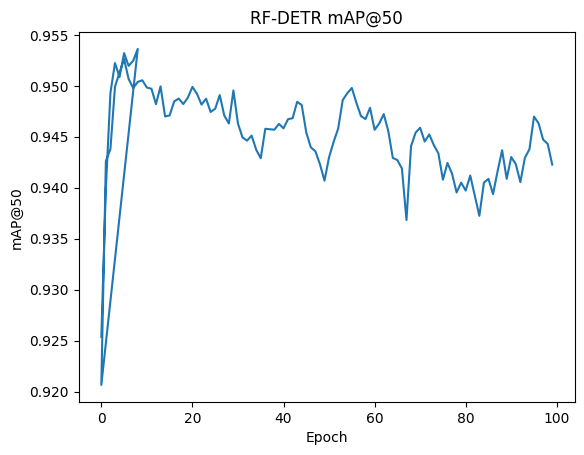

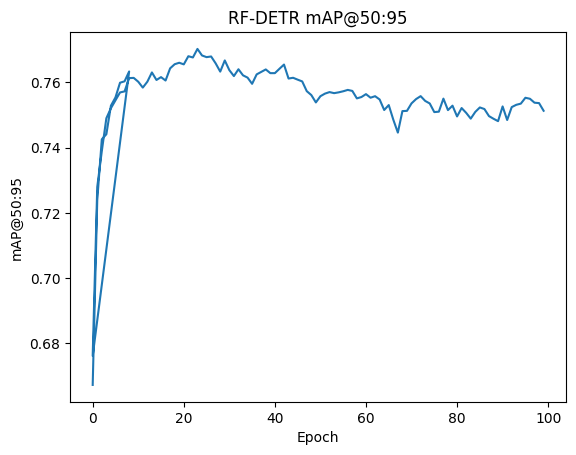

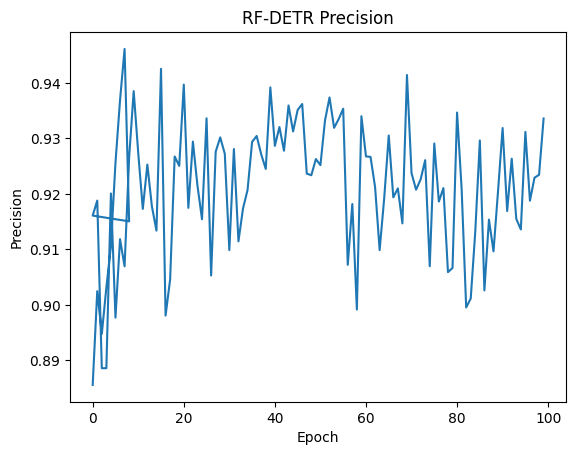

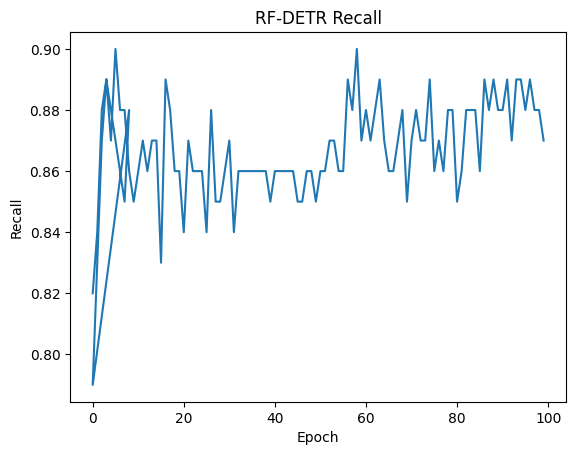

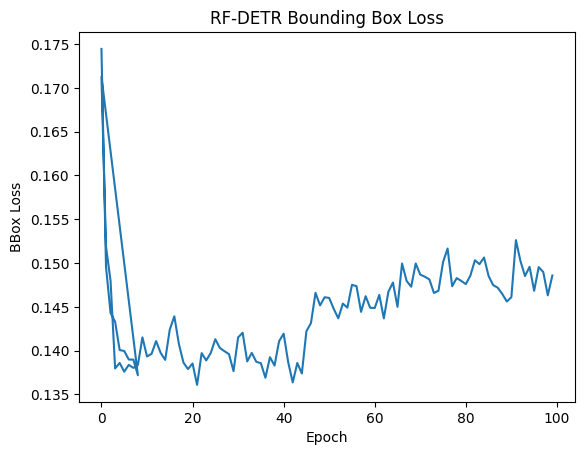

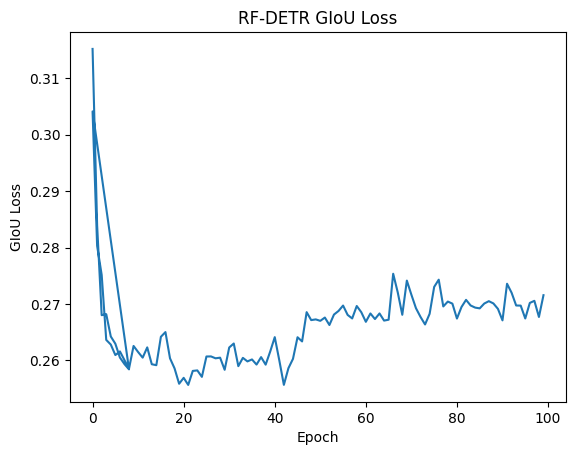

In [2]:
import json
import matplotlib.pyplot as plt

log_file = "log.txt"

epochs = []
map50 = []
map5095 = []
precision = []
recall = []
bbox_loss = []
giou_loss = []

with open(log_file, "r", encoding="utf-8") as f:
    for line in f:
        data = json.loads(line.strip())
        
        epochs.append(data["epoch"])
        
        # Use EMA metrics (more stable)
        ema_results = data["ema_test_results_json"]
        
        map50.append(ema_results["map"])
        map5095.append(ema_results["class_map"][-1]["map@50:95"])
        precision.append(ema_results["precision"])
        recall.append(ema_results["recall"])
        
        bbox_loss.append(data["ema_test_loss_bbox"])
        giou_loss.append(data["ema_test_loss_giou"])

# ---- Plot mAP ----
plt.figure()
plt.plot(epochs, map50)
plt.xlabel("Epoch")
plt.ylabel("mAP@50")
plt.title("RF-DETR mAP@50")
plt.show()

# ---- Plot mAP@50:95 ----
plt.figure()
plt.plot(epochs, map5095)
plt.xlabel("Epoch")
plt.ylabel("mAP@50:95")
plt.title("RF-DETR mAP@50:95")
plt.show()

# ---- Plot Precision ----
plt.figure()
plt.plot(epochs, precision)
plt.xlabel("Epoch")
plt.ylabel("Precision")
plt.title("RF-DETR Precision")
plt.show()

# ---- Plot Recall ----
plt.figure()
plt.plot(epochs, recall)
plt.xlabel("Epoch")
plt.ylabel("Recall")
plt.title("RF-DETR Recall")
plt.show()

# ---- Plot BBox Loss ----
plt.figure()
plt.plot(epochs, bbox_loss)
plt.xlabel("Epoch")
plt.ylabel("BBox Loss")
plt.title("RF-DETR Bounding Box Loss")
plt.show()

# ---- Plot GIoU Loss ----
plt.figure()
plt.plot(epochs, giou_loss)
plt.xlabel("Epoch")
plt.ylabel("GIoU Loss")
plt.title("RF-DETR GIoU Loss")
plt.show()


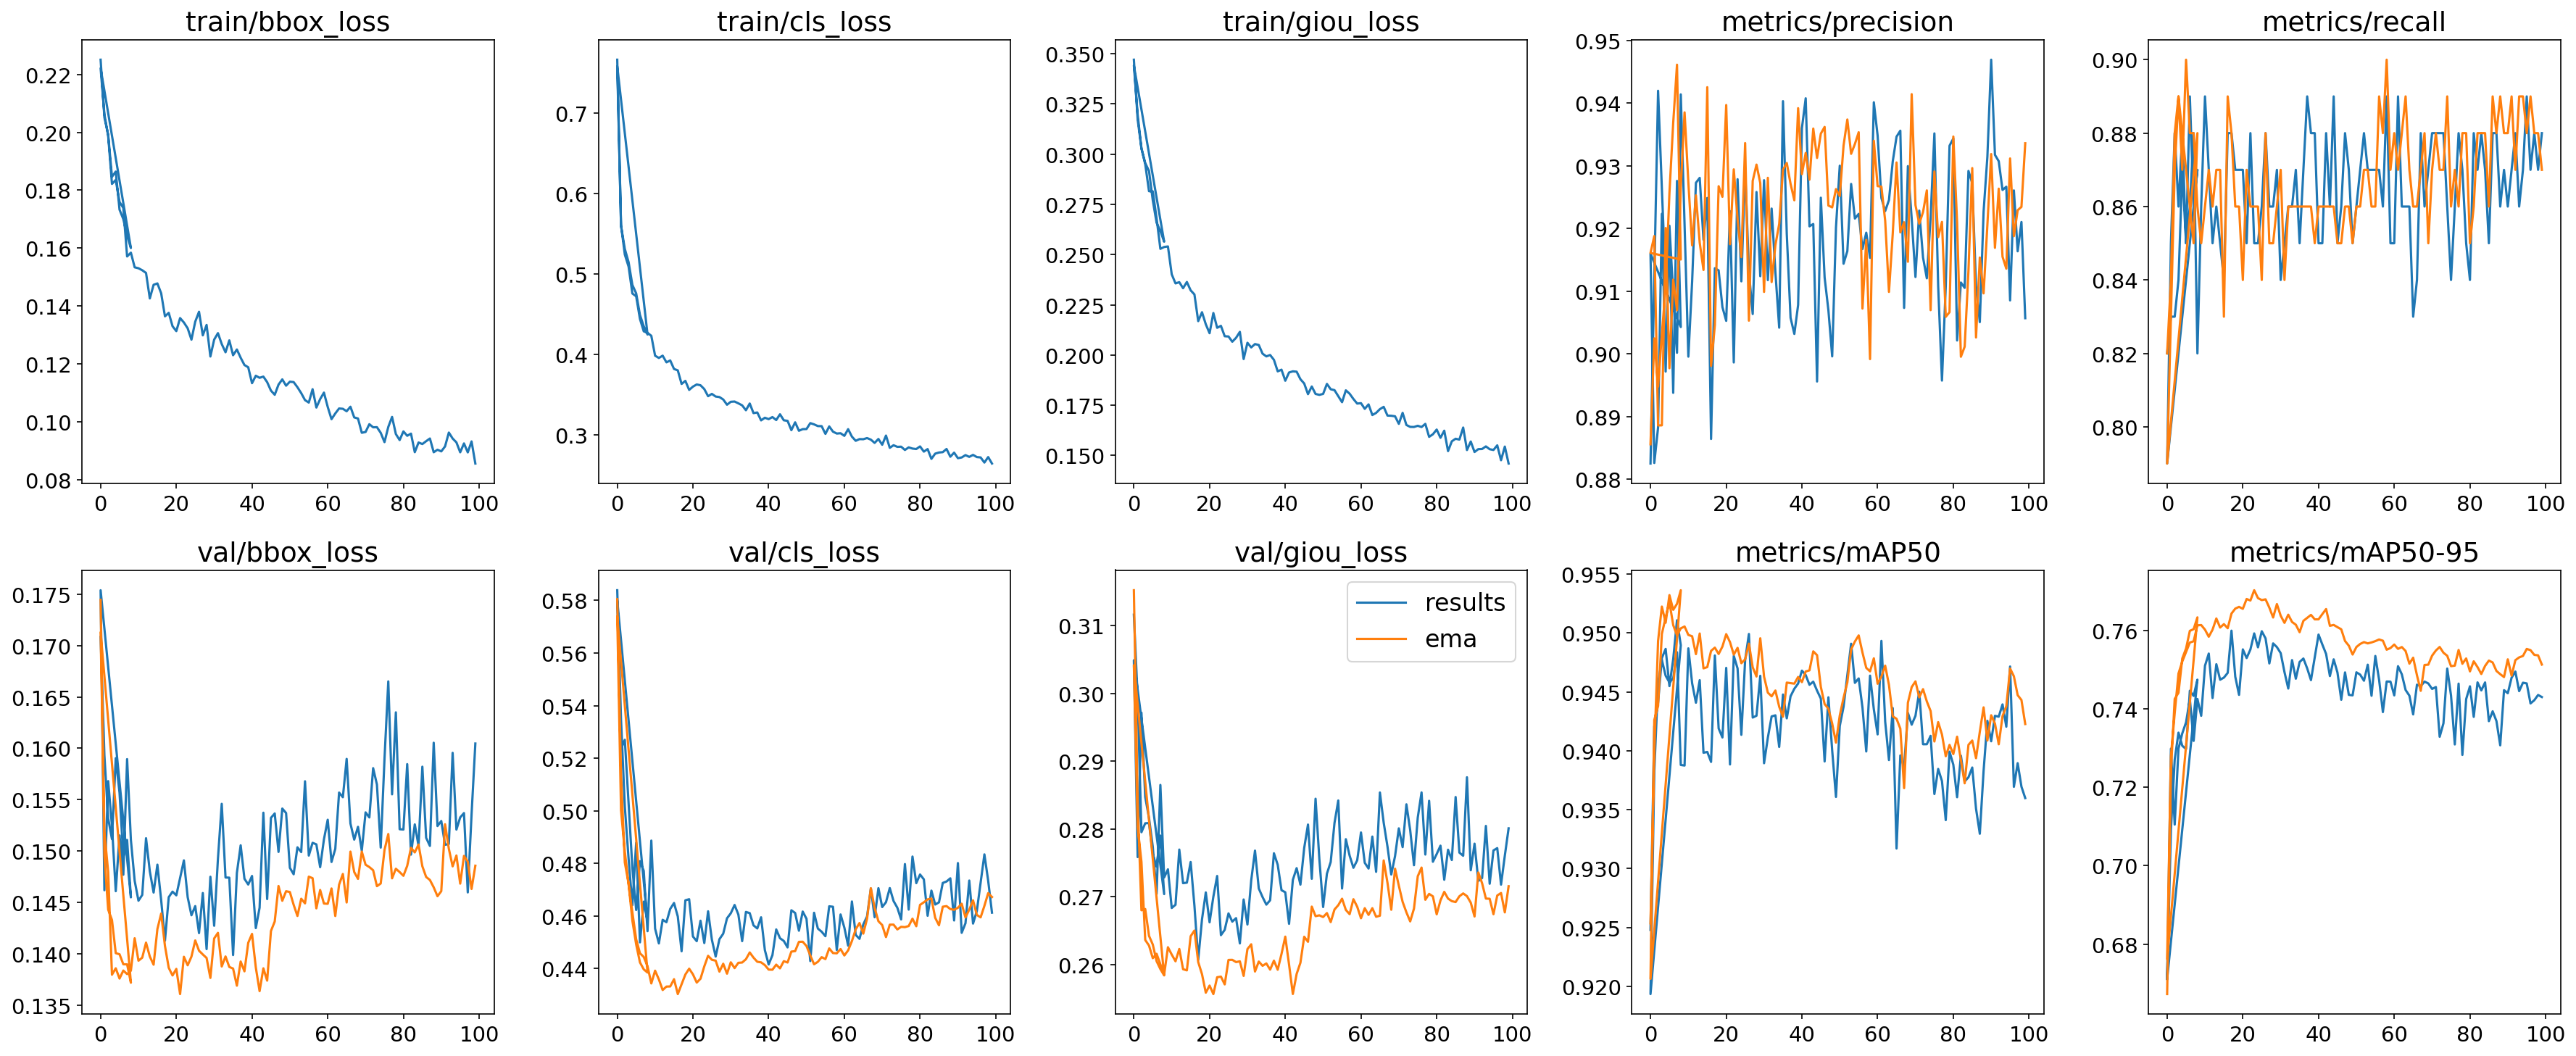

In [15]:
import json
import matplotlib.pyplot as plt

plt.rcParams.update({
    "font.size": 16,
    "axes.titlesize": 18,
    "axes.labelsize": 16,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
})

log_file = "log.txt"

epochs = []

train_bbox = []
train_ce = []
train_giou = []

test_bbox = []
test_ce = []
test_giou = []
test_map50 = []
test_map5095 = []
test_precision = []
test_recall = []

ema_bbox = []
ema_ce = []
ema_giou = []
ema_map50 = []
ema_map5095 = []
ema_precision = []
ema_recall = []

with open(log_file, "r", encoding="utf-8") as f:
    for line in f:
        data = json.loads(line.strip())

        epochs.append(data["epoch"])

        train_bbox.append(data["train_loss_bbox"])
        train_ce.append(data["train_loss_ce"])
        train_giou.append(data["train_loss_giou"])

        test_bbox.append(data["test_loss_bbox"])
        test_ce.append(data["test_loss_ce"])
        test_giou.append(data["test_loss_giou"])

        test_results = data["test_results_json"]
        test_map50.append(test_results["map"])
        test_map5095.append(test_results["class_map"][-1]["map@50:95"])
        test_precision.append(test_results["precision"])
        test_recall.append(test_results["recall"])

        ema_bbox.append(data["ema_test_loss_bbox"])
        ema_ce.append(data["ema_test_loss_ce"])
        ema_giou.append(data["ema_test_loss_giou"])

        ema_results = data["ema_test_results_json"]
        ema_map50.append(ema_results["map"])
        ema_map5095.append(ema_results["class_map"][-1]["map@50:95"])
        ema_precision.append(ema_results["precision"])
        ema_recall.append(ema_results["recall"])


fig, ax = plt.subplots(2, 5, figsize=(24, 10), dpi=150)

# Row 1
ax[0,0].plot(epochs, train_bbox)
ax[0,0].set_title("train/bbox_loss")

ax[0,1].plot(epochs, train_ce)
ax[0,1].set_title("train/cls_loss")

ax[0,2].plot(epochs, train_giou)
ax[0,2].set_title("train/giou_loss")

l1, = ax[0,3].plot(epochs, test_precision)
l2, = ax[0,3].plot(epochs, ema_precision)
ax[0,3].set_title("metrics/precision")

ax[0,4].plot(epochs, test_recall)
ax[0,4].plot(epochs, ema_recall)
ax[0,4].set_title("metrics/recall")

# Row 2
ax[1,0].plot(epochs, test_bbox)
ax[1,0].plot(epochs, ema_bbox)
ax[1,0].set_title("val/bbox_loss")

ax[1,1].plot(epochs, test_ce)
ax[1,1].plot(epochs, ema_ce)
ax[1,1].set_title("val/cls_loss")

ax[1,2].plot(epochs, test_giou)
ax[1,2].plot(epochs, ema_giou)
ax[1,2].set_title("val/giou_loss")
ax[1,2].legend(["results", "ema"], loc="upper right")

ax[1,3].plot(epochs, test_map50)
ax[1,3].plot(epochs, ema_map50)
ax[1,3].set_title("metrics/mAP50")

ax[1,4].plot(epochs, test_map5095)
ax[1,4].plot(epochs, ema_map5095)
ax[1,4].set_title("metrics/mAP50-95")


plt.tight_layout()
plt.show()
